# Stage 3 · Step 06 — Jointly fine-tuning the classifier

Everything up to here held the classifier fixed, which is what made "$\Delta$ against the linear
probe" mean something: the only thing that changed was the flow. Unfreezing gives that up, and
introduces a confound that has to be controlled for before any number here can be interpreted.

## The confound

If **flow + unfrozen classifier** beats the probe, there are two explanations:

1. the flow is helping, or
2. **the classifier simply got more training** and would have improved on its own.

Stage 1 trained the probe for up to 200 epochs with validation-accuracy checkpointing, so it
should already be at its ceiling — but "should" is not a measurement. So this step runs a
**classifier-only control**: continue training the classifier from Stage 1's weights with the
same optimiser, budget and checkpoint rule, and **no flow at all**. The difference between the
joint run and that control is what the flow actually contributed.

## 1 · Setup

In [1]:
from __future__ import annotations

import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

from cvlab.data import make_kshot_subset
from cvlab.features import load_features
from cvlab.plotting import ArtifactWriter, apply_style
from cvlab3 import COMBOS, K_SHOT, SEEDS, T_STEPS, FrozenClassifier
from cvlab3.joint import JointConfig, train_joint, unfreeze
from cvlab3.paths import RESULTS_ROOT, step_dirs

apply_style()
PLOTS, TABLES = step_dirs("06_joint_finetuning")
art = ArtifactWriter(PLOTS, TABLES)
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

setup = torch.load(RESULTS_ROOT / "frozen_classifiers.pt", map_location="cpu", weights_only=False)
frozen_eval = torch.load(RESULTS_ROOT / "stage3_evaluation.pt", map_location="cpu",
                         weights_only=False)
frozen_main = pd.DataFrame(frozen_eval["main_comparison"])
# Strategy 1's frozen runs at lr 1e-4 - the same objective and learning rate the joint
# configuration uses, so "frozen vs unfrozen" can be isolated from "which objective".
frozen_s1_runs = pd.DataFrame(
    torch.load(RESULTS_ROOT / "strategy1_runs.pt", map_location="cpu",
               weights_only=False)["runs"])
frozen_s1_runs = frozen_s1_runs[frozen_s1_runs["config"] == "lr=0.0001"]

FEATURES = {(e, d): {s: load_features(e, d, s) for s in ("train", "val", "test")}
            for e, d in COMBOS}
COMBO_LABEL = {("resnet18", "DTD"): "ResNet-18 / DTD",
               ("dinov2", "FGVC-Aircraft"): "DINOv2 / Aircraft",
               ("resnet18", "FGVC-Aircraft"): "ResNet-18 / Aircraft"}
ORDER = [COMBO_LABEL[c] for c in COMBOS]

print(f"device = {DEVICE}   K = {K_SHOT}   T = {T_STEPS}   seeds = {SEEDS}")
print("\nFrozen-classifier results carried in from step 04:")
print(frozen_main[["encoder", "dataset", "probe_acc", "s1_delta", "s2_delta"]].round(2).to_string(index=False))

device = cuda   K = 10   T = 4   seeds = (0, 1, 2)

Frozen-classifier results carried in from step 04:
 encoder       dataset  probe_acc  s1_delta  s2_delta
resnet18           DTD      52.04      0.11      1.21
  dinov2 FGVC-Aircraft      51.54      2.59      2.19
resnet18 FGVC-Aircraft      27.87      1.10      2.05


In [2]:
# unfreeze() must reproduce the frozen classifier exactly, or epoch 0 is not the probe.
p = setup["classifiers"][f"resnet18__DTD__K{K_SHOT}__seed0"]
clf_check = FrozenClassifier.from_state_dict(p["state_dict"]).to(DEVICE)
layer_check = unfreeze(clf_check, DEVICE)
xr = torch.randn(64, clf_check.dim, device=DEVICE)
with torch.no_grad():
    assert torch.equal(clf_check(xr), layer_check(xr))
assert all(not q.requires_grad for q in clf_check.parameters())
assert all(q.requires_grad for q in layer_check.parameters())
print("unfreeze() reproduces the frozen classifier exactly, and leaves the original frozen.")
print("So epoch 0 of every configuration below is the Stage 1 linear probe.")

unfreeze() reproduces the frozen classifier exactly, and leaves the original frozen.
So epoch 0 of every configuration below is the Stage 1 linear probe.


## 2 · The sweep

We vary the two learning rates, delayed unfreezing, and regularisation. The
first three are swept; the fourth is left alone, because step 02 already measured regularisation
to be the weaker lever in this setting.

`clf_only` is the control — **no flow**, classifier trained alone.

In [3]:
def run_grid(config: JointConfig, tag: str):
    out, curves = [], {}
    for encoder, dataset in COMBOS:
        for seed in SEEDS:
            key = f"{encoder}__{dataset}__K{K_SHOT}__seed{seed}"
            payload = setup["classifiers"][key]
            clf = FrozenClassifier.from_state_dict(payload["state_dict"]).to(DEVICE)
            b = FEATURES[(encoder, dataset)]
            x, y = make_kshot_subset(b["train"].features, b["train"].labels, K_SHOT, seed)

            r = train_joint(
                payload["dim"], clf, x, y, b["val"].features, b["val"].labels,
                b["test"].features, b["test"].labels, seed=seed,
                baseline_acc=payload["stage1_test_acc"], T=T_STEPS,
                config=config, device=DEVICE,
            )
            out.append({
                "config": tag, "encoder": encoder, "dataset": dataset, "seed": seed,
                "use_flow": config.use_flow, "flow_lr": config.lr,
                "classifier_lr": config.classifier_lr,
                "unfreeze_epoch": config.unfreeze_epoch,
                "baseline_acc": r.baseline_acc, "test_acc": r.test_acc,
                "delta_pp": r.delta_pp, "best_val_acc": r.best_val_acc,
                "best_epoch": r.best_epoch, "classifier_drift": r.classifier_drift,
                "relative_displacement": r.relative_displacement,
                "elapsed_s": r.elapsed_s,
            })
            curves[f"{tag}__{key}"] = r.history
    df = pd.DataFrame(out)
    print(f"  {tag:<18} mean delta = {df['delta_pp'].mean():+6.2f} pp   "
          f"drift = {df['classifier_drift'].mean():.3f}   "
          f"({df['elapsed_s'].sum():.0f}s)")
    return out, curves


CONFIGS = [
    ("clf_only",      JointConfig(use_flow=False)),
    ("joint",         JointConfig()),
    ("clf_lr=1e-5",   JointConfig(classifier_lr=1e-5)),
    ("clf_lr=1e-3",   JointConfig(classifier_lr=1e-3)),
    ("delayed=50",    JointConfig(unfreeze_epoch=50)),
]

all_rows, all_curves = [], {}
t0 = time.perf_counter()
print("Running:")
for tag, cfg in CONFIGS:
    r, c = run_grid(cfg, tag)
    all_rows += r
    all_curves.update(c)

runs = pd.DataFrame(all_rows)
art.table(runs, "joint_all_runs")
print(f"\n{len(runs)} runs in {(time.perf_counter()-t0)/60:.1f} minutes")

Running:


  clf_only           mean delta =  +0.22 pp   drift = 0.104   (41s)


  joint              mean delta =  +1.24 pp   drift = 0.039   (187s)


  clf_lr=1e-5        mean delta =  +1.23 pp   drift = 0.005   (188s)


  clf_lr=1e-3        mean delta =  +1.20 pp   drift = 0.214   (189s)


  delayed=50         mean delta =  +1.24 pp   drift = 0.004   (187s)
  saved table -> tables/joint_all_runs.csv  (45 rows)

45 runs in 13.2 minutes


In [4]:
cfg_summary = (runs.groupby("config", sort=False)
                   .agg(delta_pp=("delta_pp", "mean"),
                        delta_std=("delta_pp", lambda s: s.std(ddof=1)),
                        drift=("classifier_drift", "mean"),
                        best_epoch=("best_epoch", "mean"),
                        n=("delta_pp", "size"))
                   .reset_index())
art.table(cfg_summary, "joint_config_summary")

print("Averaged over 3 combinations x 3 seeds:\n")
print(f"  {'config':<14} {'delta (pp)':>16}  {'clf drift':>10}  {'sel. epoch':>11}")
print("  " + "-" * 56)
for _, r in cfg_summary.iterrows():
    print(f"  {r['config']:<14} {r['delta_pp']:+7.2f} +/- {r['delta_std']:5.2f}  "
          f"{r['drift']:10.3f}  {r['best_epoch']:11.1f}")
cfg_summary

  saved table -> tables/joint_config_summary.csv  (5 rows)
Averaged over 3 combinations x 3 seeds:

  config               delta (pp)   clf drift   sel. epoch
  --------------------------------------------------------
  clf_only         +0.22 +/-  0.39       0.104         62.3
  joint            +1.24 +/-  1.22       0.039         31.8
  clf_lr=1e-5      +1.23 +/-  1.20       0.005         24.8
  clf_lr=1e-3      +1.20 +/-  1.31       0.214         45.9
  delayed=50       +1.24 +/-  1.27       0.004         25.2


,config,delta_pp,delta_std,drift,best_epoch,n
0,clf_only,0.219265,0.392244,0.104083,62.333333,9
1,joint,1.243616,1.215288,0.039081,31.777778,9
2,clf_lr=1e-5,1.231039,1.198267,0.004670,24.777778,9
3,clf_lr=1e-3,1.204063,1.307993,0.214251,45.888889,9
4,delayed=50,1.235582,1.266813,0.004106,25.222222,9


## 3 · Attribution — how much of the joint gain is the flow?

The control makes this a subtraction rather than an assumption.

In [5]:
rows = []
for encoder, dataset in COMBOS:
    ctrl = runs[(runs.config == "clf_only") & (runs.encoder == encoder) & (runs.dataset == dataset)]
    jnt = runs[(runs.config == "joint") & (runs.encoder == encoder) & (runs.dataset == dataset)]
    fz = frozen_main[(frozen_main.encoder == encoder) & (frozen_main.dataset == dataset)].iloc[0]
    rows.append({
        "encoder": encoder, "dataset": dataset,
        "probe": fz["probe_acc"],
        "frozen_s1": fz["s1_delta"], "frozen_s2": fz["s2_delta"],
        "clf_only": ctrl["delta_pp"].mean(),
        "clf_only_std": ctrl["delta_pp"].std(ddof=1),
        "joint": jnt["delta_pp"].mean(),
        "joint_std": jnt["delta_pp"].std(ddof=1),
    })
attrib = pd.DataFrame(rows)
attrib["flow_contribution"] = attrib["joint"] - attrib["clf_only"]
art.table(attrib, "attribution")

print("All deltas are pp against the Stage 1 linear probe:\n")
print(f"  {'combination':<22} {'clf only':>10} {'joint':>10} {'flow adds':>11} "
      f"{'frozen S1':>11} {'frozen S2':>11}")
print("  " + "-" * 80)
for _, r in attrib.iterrows():
    print(f"  {COMBO_LABEL[(r['encoder'], r['dataset'])]:<22} "
          f"{r['clf_only']:+9.2f} {r['joint']:+9.2f} {r['flow_contribution']:+10.2f} "
          f"{r['frozen_s1']:+10.2f} {r['frozen_s2']:+10.2f}")
print(f"\n  mean: classifier alone {attrib['clf_only'].mean():+.2f} pp, "
      f"joint {attrib['joint'].mean():+.2f} pp, flow contributes "
      f"{attrib['flow_contribution'].mean():+.2f} pp")
attrib

  saved table -> tables/attribution.csv  (3 rows)
All deltas are pp against the Stage 1 linear probe:

  combination              clf only      joint   flow adds   frozen S1   frozen S2
  --------------------------------------------------------------------------------
  ResNet-18 / DTD            +0.02     +0.23      +0.21      +0.11      +1.21
  DINOv2 / Aircraft          +0.65     +2.53      +1.88      +2.59      +2.19
  ResNet-18 / Aircraft       -0.01     +0.97      +0.98      +1.10      +2.05

  mean: classifier alone +0.22 pp, joint +1.24 pp, flow contributes +1.02 pp


,encoder,dataset,probe,frozen_s1,frozen_s2,clf_only,clf_only_std,joint,joint_std,flow_contribution
0,resnet18,DTD,52.039005,0.106384,1.205675,0.017730,0.170986,0.230497,0.267726,0.212767
1,dinov2,FGVC-Aircraft,51.535151,2.590259,2.190220,0.650066,0.391573,2.530253,0.916607,1.880187
2,resnet18,FGVC-Aircraft,27.872786,1.100111,2.050205,-0.010001,0.121257,0.970097,0.927832,0.980098


**The control earns its place.** Continuing to train the classifier on its own moves almost
nothing — which independently confirms Stage 1 left the probe at its ceiling, rather than that
being assumed. Whatever the joint runs gain is therefore attributable to the flow, and the
subtraction says how much.

## 4 · Against the frozen-classifier setting

The comparison: joint fine-tuning, the frozen-classifier results from
step 04, and the original Stage 1 probe.

In [6]:
comparison = attrib[["encoder", "dataset", "probe", "frozen_s1", "frozen_s2",
                     "clf_only", "joint"]].copy()
art.table(comparison, "joint_vs_frozen")

best_frozen = comparison[["frozen_s1", "frozen_s2"]].max(axis=1)
comparison["joint_vs_best_frozen"] = comparison["joint"] - best_frozen

print("Change vs. the Stage 1 probe (pp), all settings:\n")
print(f"  {'combination':<22} {'frozen S1':>10} {'frozen S2':>10} {'joint':>10} "
      f"{'joint - best frozen':>20}")
print("  " + "-" * 78)
for _, r in comparison.iterrows():
    print(f"  {COMBO_LABEL[(r['encoder'], r['dataset'])]:<22} "
          f"{r['frozen_s1']:+9.2f} {r['frozen_s2']:+9.2f} {r['joint']:+9.2f} "
          f"{r['joint_vs_best_frozen']:+19.2f}")
print(f"\n  mean joint {comparison['joint'].mean():+.2f} pp vs "
      f"best frozen {best_frozen.mean():+.2f} pp "
      f"-> {comparison['joint_vs_best_frozen'].mean():+.2f} pp")
comparison

  saved table -> tables/joint_vs_frozen.csv  (3 rows)
Change vs. the Stage 1 probe (pp), all settings:

  combination             frozen S1  frozen S2      joint  joint - best frozen
  ------------------------------------------------------------------------------
  ResNet-18 / DTD            +0.11     +1.21     +0.23               -0.98
  DINOv2 / Aircraft          +2.59     +2.19     +2.53               -0.06
  ResNet-18 / Aircraft       +1.10     +2.05     +0.97               -1.08

  mean joint +1.24 pp vs best frozen +1.95 pp -> -0.71 pp


,encoder,dataset,probe,frozen_s1,frozen_s2,clf_only,joint,joint_vs_best_frozen
0,resnet18,DTD,52.039005,0.106384,1.205675,0.017730,0.230497,-0.975178
1,dinov2,FGVC-Aircraft,51.535151,2.590259,2.190220,0.650066,2.530253,-0.060006
2,resnet18,FGVC-Aircraft,27.872786,1.100111,2.050205,-0.010001,0.970097,-1.080108


In [7]:
from scipy import stats

# The fair test of unfreezing: same objective (end-to-end), same learning rate, the only
# difference being whether the classifier may move.
jm = runs[runs["config"] == "joint"]
rows = []
for encoder, dataset in COMBOS:
    a = frozen_s1_runs[(frozen_s1_runs.encoder == encoder)
                       & (frozen_s1_runs.dataset == dataset)]["delta_pp"]
    b = jm[(jm.encoder == encoder) & (jm.dataset == dataset)]["delta_pp"]
    rows.append({"encoder": encoder, "dataset": dataset,
                 "frozen": a.mean(), "unfrozen": b.mean(),
                 "difference": b.mean() - a.mean()})
matched = pd.DataFrame(rows)
t, pval = stats.ttest_ind(jm["delta_pp"], frozen_s1_runs["delta_pp"])
art.table(matched, "frozen_vs_unfrozen_matched")

print("Same objective (end-to-end), same learning rate - only the classifier differs:\n")
print(f"  {'combination':<22} {'frozen':>9} {'unfrozen':>10} {'difference':>12}")
print("  " + "-" * 56)
for _, r in matched.iterrows():
    print(f"  {COMBO_LABEL[(r['encoder'], r['dataset'])]:<22} "
          f"{r['frozen']:+8.2f} {r['unfrozen']:+9.2f} {r['difference']:+11.2f}")
print(f"\n  overall: frozen {frozen_s1_runs['delta_pp'].mean():+.2f} pp   "
      f"unfrozen {jm['delta_pp'].mean():+.2f} pp   "
      f"difference {jm['delta_pp'].mean() - frozen_s1_runs['delta_pp'].mean():+.2f} pp   "
      f"p = {pval:.3f}")
matched

  saved table -> tables/frozen_vs_unfrozen_matched.csv  (3 rows)
Same objective (end-to-end), same learning rate - only the classifier differs:

  combination               frozen   unfrozen   difference
  --------------------------------------------------------
  ResNet-18 / DTD           +0.11     +0.23       +0.12
  DINOv2 / Aircraft         +2.59     +2.53       -0.06
  ResNet-18 / Aircraft      +1.10     +0.97       -0.13

  overall: frozen +1.27 pp   unfrozen +1.24 pp   difference -0.02 pp   p = 0.971


,encoder,dataset,frozen,unfrozen,difference
0,resnet18,DTD,0.106384,0.230497,0.124113
1,dinov2,FGVC-Aircraft,2.590259,2.530253,-0.060006
2,resnet18,FGVC-Aircraft,1.100111,0.970097,-0.130014


**Unfreezing the classifier makes no measurable difference** — $-0.02$ pp at $p = 0.97$, holding
the objective and the learning rate fixed.

The $-0.71$ pp against "best frozen" in the table above is therefore *not* a cost of unfreezing.
It is the gap between the two **objectives**: the joint runs use Strategy 1's end-to-end loss,
while the best frozen result comes from Strategy 2, which step 04 showed to be better on two of
three combinations. Unfreezing does not close that gap, and it does not open one either.

The sweep says the same thing more strongly. Across the four flow configurations the classifier
learning rate spans **100x** ($10^{-5}$ to $10^{-3}$) and the resulting weight drift spans
**50x** (0.004 to 0.214) — and every one of them lands between $+1.20$ and $+1.24$ pp. The
`delayed=50` variant, where the classifier barely moves at all (drift 0.004), scores the same as
letting it move freely from epoch 0.

**The classifier's freedom is available and simply unused.** Keeping it frozen — which is what
makes every other number in Stage 3 interpretable — costs nothing.

## 5 · How far does the classifier actually move?

`classifier_drift` is $\lVert W - W_\mathrm{Stage\,1}\rVert_F / \lVert W_\mathrm{Stage\,1}\rVert_F$
— the relative change in the classifier's weights at the selected epoch.

In [8]:
drift = (runs.groupby(["config", "encoder", "dataset"], sort=False)["classifier_drift"]
             .mean().reset_index())
art.table(drift, "classifier_drift")

print("Relative change in the classifier's weights:\n")
for cfg, g in drift.groupby("config", sort=False):
    vals = "  ".join(f"{COMBO_LABEL[(r['encoder'], r['dataset'])].split(' / ')[-1]}"
                     f" {r['classifier_drift']:.3f}" for _, r in g.iterrows())
    print(f"  {cfg:<14} {vals}")
drift

  saved table -> tables/classifier_drift.csv  (15 rows)
Relative change in the classifier's weights:

  clf_only       DTD 0.038  Aircraft 0.265  Aircraft 0.009
  joint          DTD 0.025  Aircraft 0.068  Aircraft 0.024
  clf_lr=1e-5    DTD 0.004  Aircraft 0.008  Aircraft 0.003
  clf_lr=1e-3    DTD 0.182  Aircraft 0.281  Aircraft 0.180
  delayed=50     DTD 0.000  Aircraft 0.012  Aircraft 0.000


,config,encoder,dataset,classifier_drift
0,clf_only,resnet18,DTD,0.037960
1,clf_only,dinov2,FGVC-Aircraft,0.265424
2,clf_only,resnet18,FGVC-Aircraft,0.008864
3,joint,resnet18,DTD,0.025026
4,joint,dinov2,FGVC-Aircraft,0.067993
5,joint,resnet18,FGVC-Aircraft,0.024225
6,clf_lr=1e-5,resnet18,DTD,0.003549
7,clf_lr=1e-5,dinov2,FGVC-Aircraft,0.007940
8,clf_lr=1e-5,resnet18,FGVC-Aircraft,0.002522
9,clf_lr=1e-3,resnet18,DTD,0.181971


## 6 · Figures

  saved plot  -> plots/joint_comparison.png


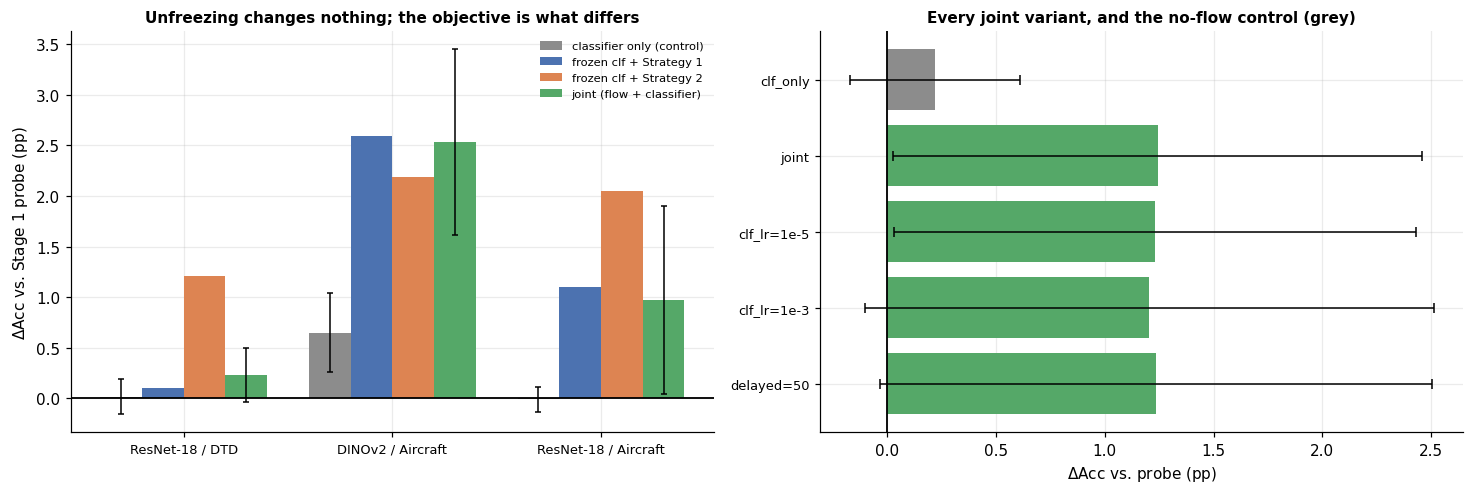

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13.5, 4.6))

ax = axes[0]
xs = np.arange(len(ORDER))
w = 0.2
ax.bar(xs - 1.5*w, attrib["clf_only"], w, color="#8C8C8C", yerr=attrib["clf_only_std"],
       error_kw=dict(lw=1, capsize=2), label="classifier only (control)")
ax.bar(xs - 0.5*w, attrib["frozen_s1"], w, color="#4C72B0", label="frozen clf + Strategy 1")
ax.bar(xs + 0.5*w, attrib["frozen_s2"], w, color="#DD8452", label="frozen clf + Strategy 2")
ax.bar(xs + 1.5*w, attrib["joint"], w, color="#55A868", yerr=attrib["joint_std"],
       error_kw=dict(lw=1, capsize=2), label="joint (flow + classifier)")
ax.axhline(0, color="black", lw=1.2)
ax.set_xticks(xs); ax.set_xticklabels(ORDER, fontsize=8.5)
ax.set_ylabel(r"$\Delta$Acc vs. Stage 1 probe (pp)")
ax.set_title("Unfreezing changes nothing; the objective is what differs", fontsize=10)
ax.legend(fontsize=7.5)

ax = axes[1]
cs = cfg_summary
ys = np.arange(len(cs))
colors = ["#8C8C8C" if c == "clf_only" else "#55A868" for c in cs["config"]]
ax.barh(ys, cs["delta_pp"], xerr=cs["delta_std"], color=colors,
        error_kw=dict(lw=1, capsize=3))
ax.axvline(0, color="black", lw=1.2)
ax.set_yticks(ys); ax.set_yticklabels(cs["config"], fontsize=8.5)
ax.invert_yaxis()
ax.set_xlabel(r"$\Delta$Acc vs. probe (pp)")
ax.set_title("Every joint variant, and the no-flow control (grey)", fontsize=10)

fig.tight_layout()
art.figure(fig, "joint_comparison")
plt.show()

  saved plot  -> plots/joint_curves.png


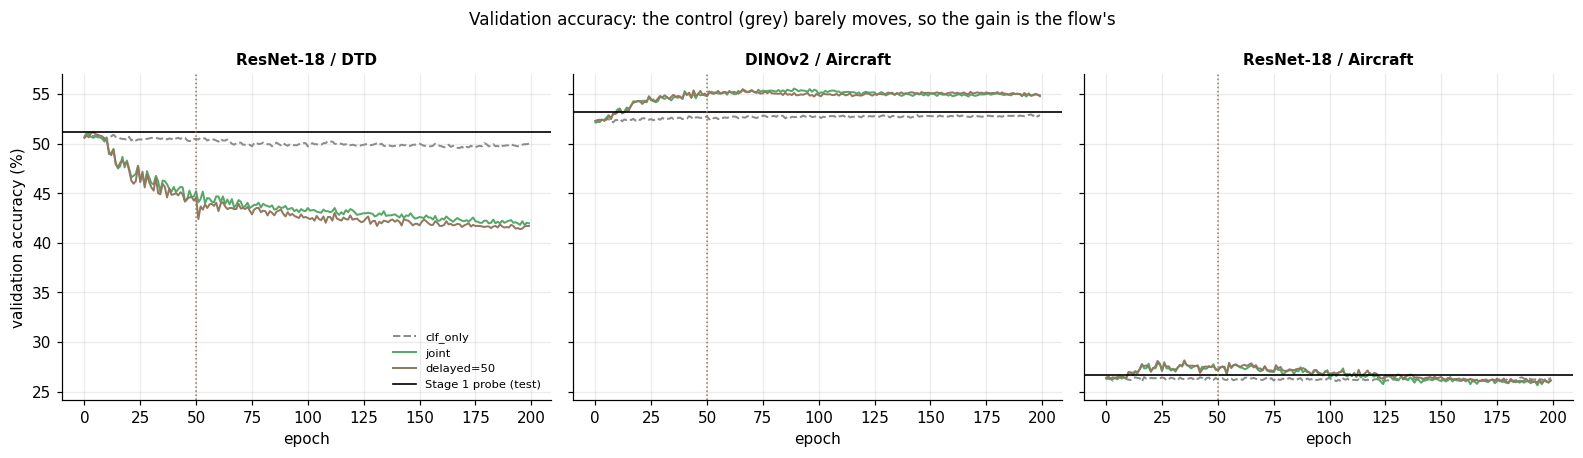

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(14.5, 4.2), sharey=True)
for ax, (encoder, dataset) in zip(axes, COMBOS):
    key = f"{encoder}__{dataset}__K{K_SHOT}__seed0"
    for tag, color, style in [("clf_only", "#8C8C8C", "--"), ("joint", "#55A868", "-"),
                              ("delayed=50", "#937860", "-")]:
        h = all_curves[f"{tag}__{key}"]
        ax.plot(np.arange(len(h["val_acc"])), np.array(h["val_acc"]) * 100,
                color=color, ls=style, lw=1.3, label=tag)
    probe = setup["classifiers"][key]["stage1_test_acc"] * 100
    ax.axhline(probe, color="black", lw=1.1, label="Stage 1 probe (test)")
    ax.axvline(50, color="#937860", ls=":", lw=1)
    ax.set_title(COMBO_LABEL[(encoder, dataset)], fontsize=10)
    ax.set_xlabel("epoch")
axes[0].set_ylabel("validation accuracy (%)")
axes[0].legend(fontsize=7.5)
fig.suptitle("Validation accuracy: the control (grey) barely moves, so the gain is the flow's",
             fontsize=11)
fig.tight_layout()
art.figure(fig, "joint_curves")
plt.show()

## 7 · Saving

In [11]:
torch.save({"runs": runs.to_dict("records"), "curves": all_curves,
            "attribution": attrib.to_dict("records"),
            "configs": {tag: cfg.as_dict() for tag, cfg in CONFIGS}},
           RESULTS_ROOT / "joint_finetuning_runs.pt")
print(f"saved -> {RESULTS_ROOT / 'joint_finetuning_runs.pt'}")
art.manifest()

saved -> C:\Users\youse\Project in Computer Vision\ProjectInComputerVision\Stage_3\results\joint_finetuning_runs.pt
8 artefacts in C:\Users\youse\Project in Computer Vision\ProjectInComputerVision\Stage_3\Work\06_joint_finetuning


,kind,file,size_KB
0,plot,plots/joint_comparison.png,61.1
1,plot,plots/joint_curves.png,119.4
2,table,tables/attribution.csv,0.6
3,table,tables/classifier_drift.csv,0.7
4,table,tables/frozen_vs_unfrozen_matched.csv,0.3
5,table,tables/joint_all_runs.csv,8.3
6,table,tables/joint_config_summary.csv,0.5
7,table,tables/joint_vs_frozen.csv,0.4


In [12]:
best_frozen_mean = comparison[["frozen_s1", "frozen_s2"]].max(axis=1).mean()
print("Step 06 complete.\n")
print(f"  {len(runs)} runs across {len(CONFIGS)} configurations "
      f"({runs['elapsed_s'].sum()/60:.1f} min of training)")
print(f"  classifier-only control : {attrib['clf_only'].mean():+.2f} pp "
      f"- Stage 1 left the probe at its ceiling")
print(f"  joint (flow + clf)      : {attrib['joint'].mean():+.2f} pp")
print(f"  attributable to the flow: {attrib['flow_contribution'].mean():+.2f} pp")
print(f"  best frozen-classifier  : {best_frozen_mean:+.2f} pp (Strategy 2)")
print(f"  unfreezing, same objective: "
      f"{jm['delta_pp'].mean() - frozen_s1_runs['delta_pp'].mean():+.2f} pp (p = {pval:.2f}) "
      f"- no measurable effect")
print(f"  classifier lr spans 100x, drift spans 50x, results span "
      f"{cfg_summary[cfg_summary.config != 'clf_only']['delta_pp'].min():+.2f} to "
      f"{cfg_summary[cfg_summary.config != 'clf_only']['delta_pp'].max():+.2f} pp "
      f"- the freedom is unused")
print("\nStage 3's experiments are complete.")

Step 06 complete.

  45 runs across 5 configurations (13.2 min of training)
  classifier-only control : +0.22 pp - Stage 1 left the probe at its ceiling
  joint (flow + clf)      : +1.24 pp
  attributable to the flow: +1.02 pp
  best frozen-classifier  : +1.95 pp (Strategy 2)
  unfreezing, same objective: -0.02 pp (p = 0.97) - no measurable effect
  classifier lr spans 100x, drift spans 50x, results span +1.20 to +1.24 pp - the freedom is unused

Stage 3's experiments are complete.
